In [1]:
import numpy as np


In [2]:
from PIL import Image

In [3]:
import matplotlib.pyplot as plt

Image shape: (250, 250)


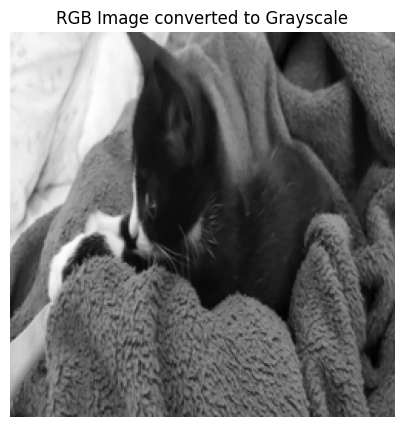

In [21]:
def img_transform(path, max_dim):
    img = Image.open(path).convert('L')
    w, h = img.size
    scale = max_dim / max(w, h)
    if scale < 1:
        img = img.resize((int(w * scale), int(h * scale)))
    return np.asarray(img, dtype=np.float64)

IMAGE_PATH = 'cat_14_svd_evd.png'
max_dimm=250
A = img_transform(IMAGE_PATH, max_dimm)
m, n = A.shape
print('Image shape:', A.shape)

plt.figure(figsize=(5,5))
plt.imshow(A, cmap='gray')
plt.title('RGB Image converted to Grayscale')
plt.axis('off')
plt.show()

In [22]:
def find_ATA(A):
    #finding A^TA
    n = A.shape[1]
    G = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            val = np.sum(A[:, i] * A[:, j])
            G[i, j] = val
            G[j, i] = val
    return G


def matvec(A, v):
    #find U
    return np.array([np.sum(A[i, :] * v) for i in range(A.shape[0])])




In [23]:
def outer_prod(u, v):

    return u.reshape(-1, 1) * v.reshape(1, -1) # to reconstruct Ak, uvt


def frobenius_norm(M):
    #Frobenius norm to measure reconstruction error
    return np.sqrt(np.sum(np.abs(M) ** 2))

In [24]:
def creat_svd_via_eig(A):
    AtA = find_ATA(A)
    eigvals, V = np.linalg.eigh(AtA)               # find eigen value and eigen vector
    order = np.argsort(-eigvals)                   # sorting the eigen values
    eigvals = np.clip(eigvals[order], 0, None)      # values below 0 become 0 and arrange
    V = V[:, order]                                 # order eigenvector acc to eigen value
    sing = np.sqrt(eigvals)                        # sigma = sqrt(eigenvalue)

    m, n = A.shape
    r = sing.shape[0]
    U = np.zeros((m, r))
    for i in range(r):
        if sing[i] > 1e-10:
            U[:, i] = matvec(A, V[:, i]) / sing[i]   # ui = A vi / sigma_i
        else:
            U[:, i] = 0.0
    return U, sing, V

U, sing, V = creat_svd_via_eig(A)
print('U:', U.shape, ' singular values:', sing.shape, ' V:', V.shape)
print('Top 10 singular values:', np.round(sing[:10], 2))

U: (250, 250)  singular values: (250,)  V: (250, 250)
Top 10 singular values: [24737.52  5153.1   3472.05  2864.55  2416.75  2211.25  1870.73  1644.57
  1498.48  1361.03]


In [27]:
def reconstruct_svd(U, sing, V, k):
    """Ak = sum_{i=1}^{k} sigma_i * outer(U[:,i], V[:,i])"""
    m = U.shape[0]
    n = V.shape[0]
    Ak = np.zeros((m, n))
    for i in range(k):
        Ak += sing[i] * outer_prod(U[:, i], V[:, i])
    return Ak

k=10   Frobenius error E(k) = 3674.764
k=40   Frobenius error E(k) = 1748.856
k=80   Frobenius error E(k) = 826.252


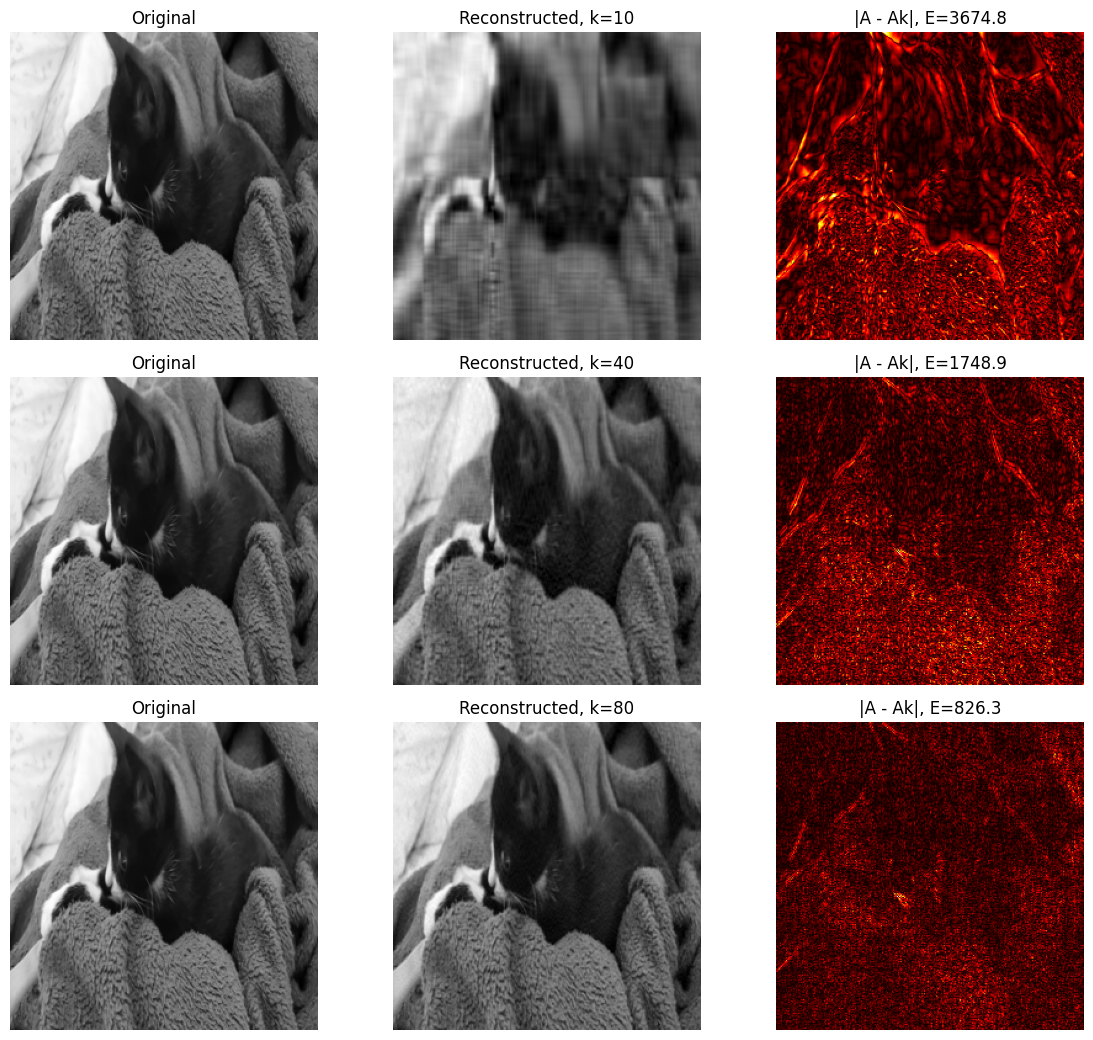

In [28]:
max_k = min(m, n)
k_values = (10, 40, 80)
k_values = [min(k, max_k) for k in k_values]

fig, axes = plt.subplots(len(k_values), 3, figsize=(12, 3.5*len(k_values)))
for row, k in enumerate(k_values):
    Ak = reconstruct_svd(U, sing, V, k)
    err = np.abs(A - Ak)
    E = frobenius_norm(A - Ak)
    print(f'k={k}   Frobenius error E(k) = {E:.3f}')

    axes[row,0].imshow(A, cmap='gray');                    axes[row,0].set_title('Original')
    axes[row,1].imshow(np.clip(Ak,0,255), cmap='gray');     axes[row,1].set_title(f'Reconstructed, k={k}')
    axes[row,2].imshow(err, cmap='hot');                    axes[row,2].set_title(f'|A - Ak|, E={E:.1f}')
    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
plt.show()

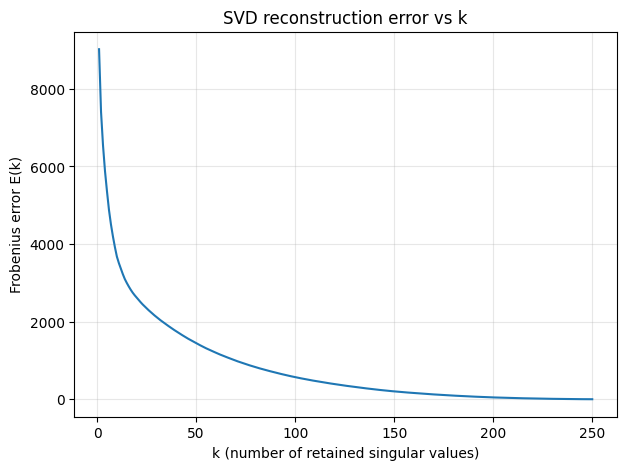

In [29]:
E_all = np.zeros(max_k)
Ak_running = np.zeros((m, n))
for i in range(max_k):
    Ak_running = Ak_running + sing[i] * outer_prod(U[:, i], V[:, i])
    E_all[i] = frobenius_norm(A - Ak_running)

plt.figure(figsize=(7,5))
plt.plot(np.arange(1, max_k+1), E_all)
plt.xlabel('k (number of retained singular values)')
plt.ylabel('Frobenius error E(k)')
plt.title('SVD reconstruction error vs k')
plt.grid(True, alpha=0.3)
plt.show()